Attempting to load model from /Users/arnablahiry/repos/SymReg-L1-Norm/pysr/direct_equation/outputs/20260323_020048_jUwwTB_50nodes_new_best/checkpoint.pkl...


Test set : 32 cosmologies
Scaler means  : [0.3041, 0.7633, -1.0007]
Scaler scales : [0.0528, 0.0825, 0.0907]
R² on 32 test cosmologies:
  Median : 0.9939
  Mean   : 0.9937
  Min    : 0.9887
  Max    : 0.9956
  >0.99  : 31 / 32
  >0.95  : 32 / 32
── Worst 5 ──────────────────────────
   Omega_m  sigma_8      w       R2
0    0.228    0.785 -0.878  0.98875
1    0.289    0.873 -1.114  0.99123
2    0.342    0.823 -1.143  0.99184
3    0.388    0.817 -0.984  0.99207
4    0.253    0.712 -1.077  0.99245

── Best 5 ───────────────────────────
    Omega_m  sigma_8      w       R2
27    0.305    0.637 -1.081  0.99519
28    0.297    0.692 -0.973  0.99525
29    0.378    0.724 -1.109  0.99530
30    0.232    0.752 -0.938  0.99530
31    0.276    0.700 -0.948  0.99560


/var/folders/bp/qbk6vrmx3vz8pnjkwdvk9_b40000gn/T/ipykernel_96028/1980858089.py:148: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors  = cm.get_cmap(cmap)(norm(bin_idx))
/var/folders/bp/qbk6vrmx3vz8pnjkwdvk9_b40000gn/T/ipykernel_96028/1980858089.py:184: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  ax_top.errorbar(bin_cents, mean_pred, yerr=std_pred,
/var/folders/bp/qbk6vrmx3vz8pnjkwdvk9_b40000gn/T/ipykernel_96028/1980858089.py:204: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  ax_bot.errorbar(bin_cents, mean_resid, yerr=std_resid,
/var/folders/bp/qbk6vrmx3vz8pnjkwdvk9_b40000gn/T/ipyker

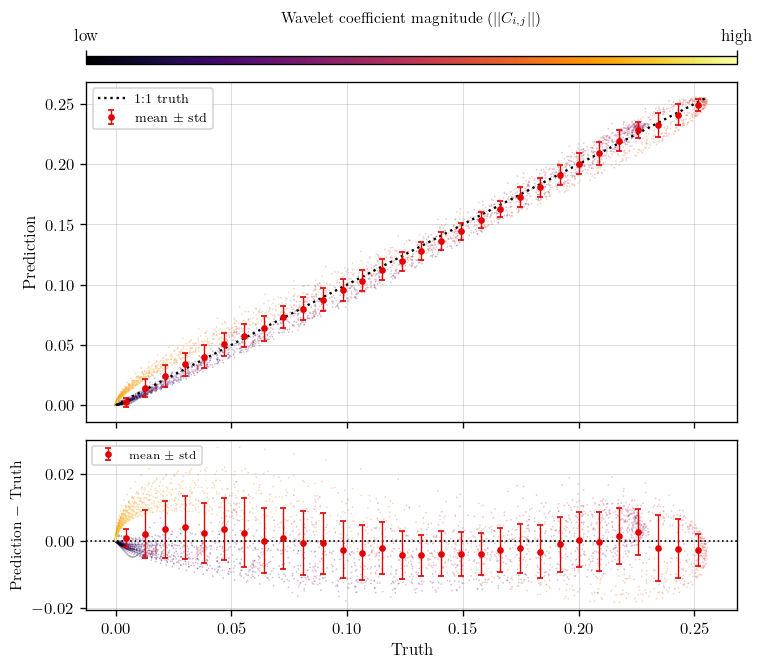

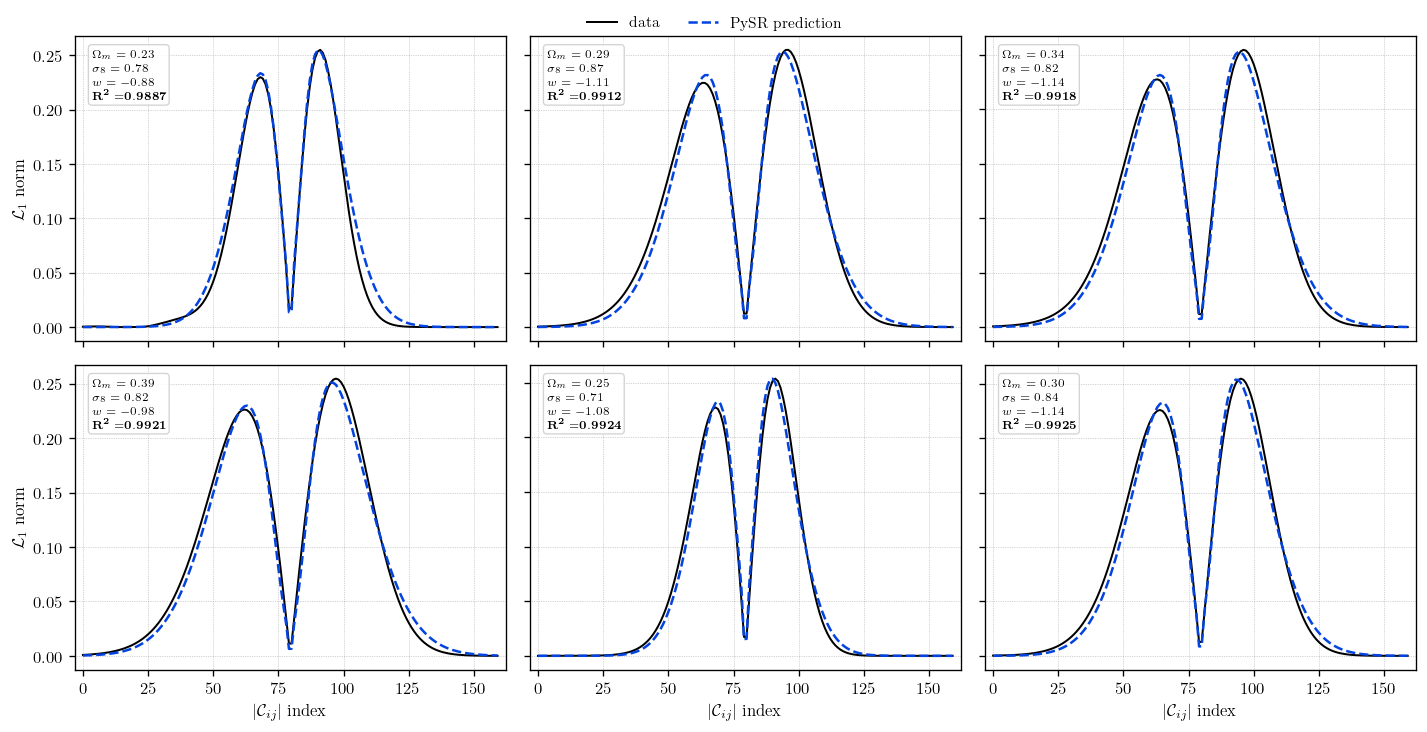

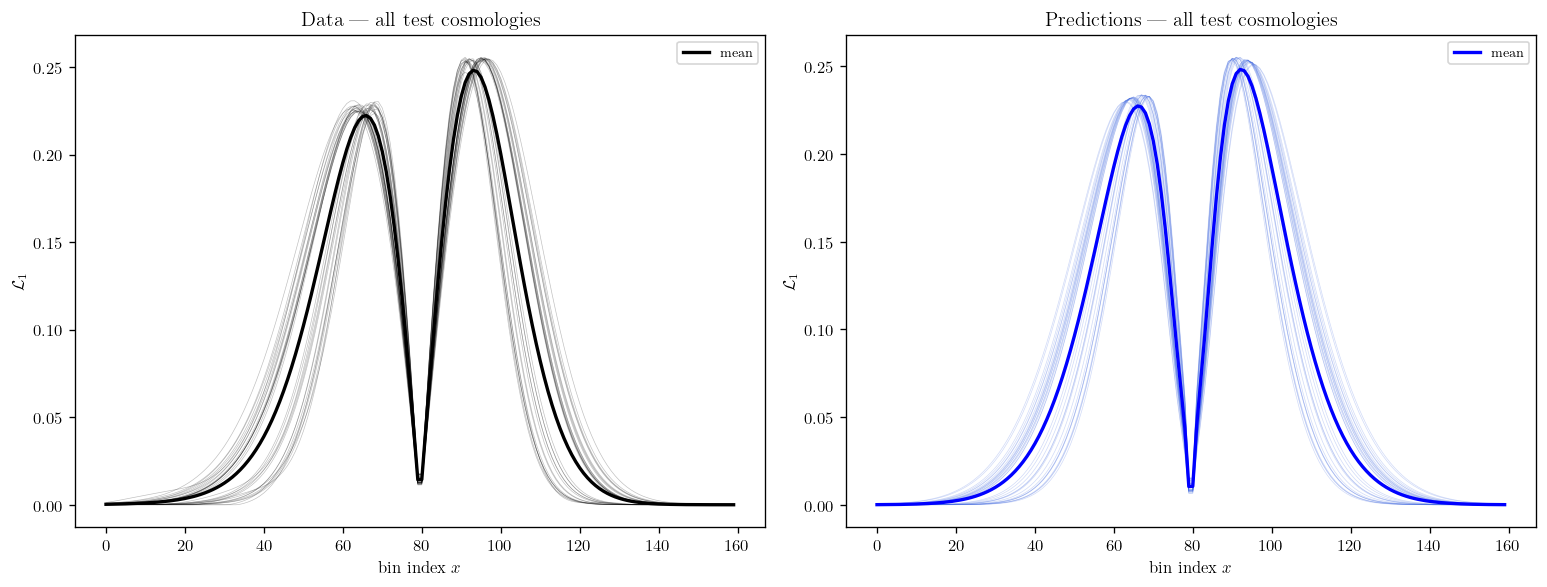

In [3]:
"""
evaluate_pysr_direct.py  —  Jupyter-friendly evaluation for PySR direct model
==============================================================================
Import this in a notebook and call the functions directly.
Every plot function returns (fig, axes) so you can keep customising.

Quickstart
----------
import numpy as np
from evaluate_pysr_direct import *

cosmo_test, dv_test, scaler = load_artifacts("symreg_direct_outputs")
x_arr  = np.arange(160)
x_c    = x_arr - mean_peak

y_preds, r2_all = run_predictions(model, cosmo_test, dv_test, x_arr, x_c, scaler)

fig, (ax_top, ax_bot) = plot_pred_vs_truth(dv_test, y_preds, x_arr)
fig, axes             = plot_worst_fits(cosmo_test, dv_test, y_preds, r2_all, x_arr)
df                    = summary_table(cosmo_test, r2_all)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pickle
import os


# =============================================================================
# UTILITIES
# =============================================================================

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0


def make_X(cosmo_row, x_c, scaler):
    N_x       = len(x_c)
    cosmo_std = scaler.transform([cosmo_row])[0]
    return np.column_stack([
        np.full(N_x, cosmo_std[0]),
        np.full(N_x, cosmo_std[1]),
        np.full(N_x, cosmo_std[2]),
        x_c,
    ])


def predict_one(model, cosmo_row, x_c, scaler):
    """Predict the L1-norm datavector for a single cosmology."""
    return model.predict(make_X(cosmo_row, x_c, scaler))


# =============================================================================
# 1.  LOAD
# =============================================================================

def load_artifacts(output_dir="symreg_direct_outputs_50nodes_new"):
    """
    Load test set and scaler saved by cosmo_symreg_direct.py.

    Returns
    -------
    cosmo_test : (N_test, 3)
    dv_test    : (N_test, 160)
    scaler     : fitted StandardScaler
    """
    with open(os.path.join(output_dir, "test_cosmologies.pkl"), "rb") as f:
        d = pickle.load(f)
    with open(os.path.join(output_dir, "cosmo_scaler.pkl"), "rb") as f:
        scaler = pickle.load(f)
    print(f"Test set : {d['cosmo'].shape[0]} cosmologies")
    print(f"Scaler means  : {scaler.mean_.round(4).tolist()}")
    print(f"Scaler scales : {scaler.scale_.round(4).tolist()}")
    return d["cosmo"], d["dv"], scaler


# =============================================================================
# 2.  PREDICT ALL
# =============================================================================

def run_predictions(model, cosmo_test, dv_test, x_arr, x_c, scaler):
    """
    Predict all test cosmologies and compute R².

    Returns
    -------
    y_preds : (N_test, 160)
    r2_all  : (N_test,)
    """
    N = cosmo_test.shape[0]
    y_preds = np.zeros((N, len(x_arr)))
    r2_all  = np.zeros(N)
    for i in range(N):
        y_preds[i] = model.predict(make_X(cosmo_test[i], x_c, scaler))
        r2_all[i]  = r2(dv_test[i], y_preds[i])
    print(f"R² on {N} test cosmologies:")
    print(f"  Median : {np.median(r2_all):.4f}")
    print(f"  Mean   : {np.mean(r2_all):.4f}")
    print(f"  Min    : {np.min(r2_all):.4f}")
    print(f"  Max    : {np.max(r2_all):.4f}")
    print(f"  >0.99  : {(r2_all > 0.99).sum()} / {N}")
    print(f"  >0.95  : {(r2_all > 0.95).sum()} / {N}")
    return y_preds, r2_all


# =============================================================================
# 3.  INDEX HELPERS
# =============================================================================

def best_idx(r2_all, n=6):
    return np.argsort(r2_all)[-n:][::-1]

def worst_idx(r2_all, n=6):
    return np.argsort(r2_all)[:n]

def random_idx(r2_all, n=6, seed=42):
    return np.random.default_rng(seed).choice(len(r2_all), n, replace=False)

plt.rcParams.update({
    "text.usetex":        True,
    "font.family":        "serif",
    "font.serif":         ["Computer Modern Roman"],
})


# =============================================================================
# 4.  PLOT: PREDICTION vs TRUTH  +  RESIDUAL SCATTER
# =============================================================================

def plot_pred_vs_truth(dv_test, y_preds, x_arr,
                        figsize=(7, 6), dpi=120,
                        n_mean_bins=30,
                        scatter_alpha=0.5,
                        cmap="inferno"):


    N_cosmo, N_x = dv_test.shape
    truth   = dv_test.ravel()
    pred    = y_preds.ravel()
    resid   = pred - truth
    bin_idx = np.tile(np.arange(N_x), N_cosmo).astype(float)
    norm    = mcolors.Normalize(vmin=0, vmax=N_x - 1)
    colors  = cm.get_cmap(cmap)(norm(bin_idx))

    # ── Layout: colorbar row on top, then two plot rows ───────────────────────
    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs  = fig.add_gridspec(3, 1,
                            height_ratios=[0.05, 2, 1],
                            hspace=0.10)
    ax_cbar = fig.add_subplot(gs[0])
    ax_top  = fig.add_subplot(gs[1])
    ax_bot  = fig.add_subplot(gs[2], sharex=ax_top)

    # ── Colorbar at top, horizontal ───────────────────────────────────────────
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=ax_cbar, orientation="horizontal")
    cbar.set_label("Wavelet coefficient magnitude $(||C_{i,j}||)$", fontsize=9, labelpad=4)
    cbar.set_ticks([0, N_x - 1])
    cbar.set_ticklabels(["low", "high"])
    ax_cbar.xaxis.set_ticks_position("top")
    ax_cbar.xaxis.set_label_position("top")

    # ── Top: pred vs truth ────────────────────────────────────────────────────
    ax_top.scatter(truth, pred,
                   c=colors, alpha=scatter_alpha, s=1,
                   rasterized=True, linewidths=0)

    lim = [min(truth.min(), pred.min()), max(truth.max(), pred.max())]
    ax_top.plot(lim, lim, "k:", lw=1.4, label="1:1 truth", zorder=5)

    bins      = np.linspace(truth.min(), truth.max(), n_mean_bins + 1)
    bin_cents = 0.5 * (bins[:-1] + bins[1:])
    dig       = np.clip(np.digitize(truth, bins) - 1, 0, n_mean_bins - 1)
    mean_pred = np.array([pred[dig == b].mean() if (dig == b).any() else np.nan
                           for b in range(n_mean_bins)])
    std_pred  = np.array([pred[dig == b].std()  if (dig == b).any() else np.nan
                           for b in range(n_mean_bins)])
    ax_top.errorbar(bin_cents, mean_pred, yerr=std_pred,
                    fmt="ro", ms=3, lw=1.5, elinewidth=0.8,
                    capsize=2, label=r"mean $\pm$ std",
                    color="xkcd:red", zorder=6)

    ax_top.set_ylabel("Prediction", fontsize=10)
    ax_top.legend(fontsize=8, loc="upper left")
    ax_top.tick_params(labelbottom=False)
    ax_top.grid(True, color="grey", linewidth=0.4, alpha=0.4, zorder=0)

    # ── Bottom: residual vs truth ─────────────────────────────────────────────
    ax_bot.scatter(truth, resid,
                   c=colors, alpha=scatter_alpha, s=1,
                   rasterized=True, linewidths=0)
    ax_bot.axhline(0, color="k", lw=1.0, ls=":", zorder=5)

    mean_resid = np.array([resid[dig == b].mean() if (dig == b).any() else np.nan
                            for b in range(n_mean_bins)])
    std_resid  = np.array([resid[dig == b].std()  if (dig == b).any() else np.nan
                            for b in range(n_mean_bins)])
    ax_bot.errorbar(bin_cents, mean_resid, yerr=std_resid,
                    fmt="ro", ms=3, lw=1.5, elinewidth=0.8,
                    capsize=2, label=r"mean $\pm$ std",
                    color="xkcd:red", zorder=6)

    ax_bot.set_xlabel("Truth", fontsize=10)
    ax_bot.set_ylabel("Prediction $-$ Truth", fontsize=9)
    ax_bot.legend(fontsize=7, loc="upper left")
    ax_bot.grid(True, color="grey", linewidth=0.4, alpha=0.4, zorder=0)

    plt.tight_layout()
    return fig, (ax_top, ax_bot, ax_cbar)


# =============================================================================
# 6.  PLOT: RECONSTRUCTIONS  (general purpose)
# =============================================================================


def plot_reconstructions(cosmo_test, dv_test, y_preds, r2_all, x_arr, idx,
                          ncols=3, figsize=None, dpi=120,
                          data_kw=None, pred_kw=None,
                          title_fn=None, suptitle=None):

    _data_kw = {"color": "k",         "lw": 1.2}
    _pred_kw = {"color": "royalblue", "lw": 1.5, "ls": "--"}
    if data_kw: _data_kw.update(data_kw)
    if pred_kw: _pred_kw.update(pred_kw)

    idx   = np.asarray(idx)
    n     = len(idx)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=figsize or (4*ncols, 3*nrows),
                              dpi=dpi)
    axes = np.array(axes).flatten()

    line_data = line_pred = None

    for pos, (ax, i) in enumerate(zip(axes, idx)):
        Om, s8, w = cosmo_test[i]
        row, col  = divmod(pos, ncols)

        ld, = ax.plot(x_arr, dv_test[i], **_data_kw)
        lp, = ax.plot(x_arr, y_preds[i], **_pred_kw)
        line_data, line_pred = ld, lp

        # Cosmological params + bold R² inside panel
        txt = (f"$\\Omega_m = {Om:.2f}$\n"
               f"$\\sigma_8 = {s8:.2f}$\n"
               f"$w = {w:.2f}$\n"
               r"$\mathbf{R^2 = }$" + f"$\\mathbf{{{r2_all[i]:.4f}}}$")
        ax.text(0.04, 0.96, txt,
                transform=ax.transAxes,
                fontsize=7, va="top", ha="left", linespacing=1.5,
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="white", alpha=0.85,
                          edgecolor="#cccccc", linewidth=0.8))

        if title_fn is not None:
            ax.set_title(title_fn(i, Om, s8, w, r2_all[i]), fontsize=8)

        # x label only on last row
        if row == nrows - 1:
            ax.set_xlabel("$|\\mathcal{{C}}_{ij}|$ index")
        else:
            ax.tick_params(labelbottom=False)

        # y label only on first column
        if col == 0:
            ax.set_ylabel("$\\mathcal{{L}}_1$ norm")
        else:
            ax.tick_params(labelleft=False)

        ax.margins(x=0.02)
        ax.grid(True, color="grey", linewidth=0.4, alpha=0.7,
                zorder=0, linestyle=":")

    for ax in axes[n:]:
        ax.set_visible(False)

    # Common horizontal legend above the figure, no frame
    if line_data is not None:
        fig.legend(
            [line_data, line_pred],
            ["data", "PySR prediction"],
            loc="upper center",
            ncol=2,
            fontsize=9,
            frameon=False,
            bbox_to_anchor=(0.5, 1.02),
        )

    if suptitle:
        fig.suptitle(suptitle, fontsize=11, y=1.06)

    plt.tight_layout()
    return fig, axes

# =============================================================================
# 7.  PLOT: OVERLAY ALL
# =============================================================================

def plot_overlay(cosmo_test, dv_test, y_preds, x_arr,
                 figsize=(13, 5), dpi=120,
                 data_kw=None, pred_kw=None):
    """
    Overlay all test cosmology curves on two side-by-side axes.

    Returns
    -------
    fig, (ax_data, ax_pred)
    """
    _data_kw = {"lw": 0.4, "alpha": 0.25, "color": "k"}
    _pred_kw = {"lw": 0.4, "alpha": 0.25, "color": "royalblue"}
    if data_kw: _data_kw.update(data_kw)
    if pred_kw: _pred_kw.update(pred_kw)

    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=dpi)
    for i in range(len(dv_test)):
        axes[0].plot(x_arr, dv_test[i], **_data_kw)
        axes[1].plot(x_arr, y_preds[i], **_pred_kw)

    axes[0].plot(x_arr, dv_test.mean(axis=0), "k-", lw=2, label="mean")
    axes[1].plot(x_arr, y_preds.mean(axis=0), "b-", lw=2, label="mean")

    for ax, t in zip(axes, ["Data — all test cosmologies",
                              "Predictions — all test cosmologies"]):
        ax.set_xlabel("bin index $x$")
        ax.set_ylabel("$\\mathcal{{L}}_1$")
        ax.set_title(t)
        ax.legend(fontsize=8)

    plt.tight_layout()
    return fig, axes


# =============================================================================
# 8.  SUMMARY TABLE
# =============================================================================

def summary_table(cosmo_test, r2_all, n=5):
    """
    DataFrame of R² per cosmology sorted worst→best.
    Prints n worst and n best rows.

    Returns
    -------
    df : pandas DataFrame
    """
    df = pd.DataFrame({
        "Omega_m": cosmo_test[:, 0].round(3),
        "sigma_8": cosmo_test[:, 1].round(3),
        "w":       cosmo_test[:, 2].round(3),
        "R2":      r2_all.round(5),
    }).sort_values("R2").reset_index(drop=True)

    print(f"── Worst {n} ──────────────────────────")
    print(df.head(n).to_string())
    print(f"\n── Best {n} ───────────────────────────")
    print(df.tail(n).to_string())
    return df


import numpy as np
from pysr import PySRRegressor

# ── Load ──────────────────────────────────────────────────────────────────────
cosmo_test, dv_test, scaler = load_artifacts("/Users/arnablahiry/repos/SymReg-L1-Norm/pysr/direct_equation/symreg_direct_outputs_50nodes_new")
x_arr     = np.arange(160)
mean_peak = 79.5
x_c       = x_arr - mean_peak

model = PySRRegressor.from_file(
    run_directory="/Users/arnablahiry/repos/SymReg-L1-Norm/pysr/direct_equation/outputs/20260323_020048_jUwwTB_50nodes_new_best"
)

# ── Predict ───────────────────────────────────────────────────────────────────
y_preds, r2_all = run_predictions(model, cosmo_test, dv_test, x_arr, x_c, scaler)

# ── Summary table ─────────────────────────────────────────────────────────────
df = summary_table(cosmo_test, r2_all)

# ── Prediction vs truth + residual scatter ────────────────────────────────────
fig, (ax_top, ax_bot, ax_cbar) = plot_pred_vs_truth(dv_test, y_preds, x_arr, scatter_alpha=0.3)
fig.savefig("pred_vs_truth.pdf", bbox_inches="tight")


# ── General reconstructions for any index set ─────────────────────────────────
fig, axes = plot_reconstructions(
    cosmo_test, dv_test, y_preds, r2_all, x_arr,
    idx=worst_idx(r2_all),
    pred_kw={"color": "xkcd:blue", "ls": "--"},
)
#ig.savefig("best_fits.pdf", bbox_inches="tight")

# ── Overlay all test cosmologies ──────────────────────────────────────────────
fig, (ax_data, ax_pred) = plot_overlay(cosmo_test, dv_test, y_preds, x_arr)
fig.savefig("overlay.pdf", bbox_inches="tight")

In [7]:
def display_equation(mean_peak, scaler, hall_of_fame_csv, complexity=34):
    """
    Render a PySR expression from the hall of fame CSV as formatted LaTeX.
    
    Parameters
    ----------
    mean_peak        : float — x centring offset from training
    scaler           : fitted StandardScaler
    hall_of_fame_csv : str  — path to hall_of_fame.csv
    complexity       : int  — which complexity to display (default 34)
    """
    import pandas as pd
    from IPython.display import display, Math
    import sympy
    from sympy import Float
    from sympy.printing.latex import LatexPrinter

    Om_mean, s8_mean, w_mean = scaler.mean_
    Om_std,  s8_std,  w_std  = scaler.scale_

    # ── Load expression from CSV ──────────────────────────────────────────────
    hof = pd.read_csv(hall_of_fame_csv)
    row = hof[hof["Complexity"] == complexity]
    if len(row) == 0:
        available = sorted(hof["Complexity"].tolist())
        raise ValueError(f"Complexity {complexity} not found. Available: {available}")

    eq_str = row["Equation"].iloc[0]
    loss   = row["Loss"].iloc[0]

    # ── Parse with sympy ──────────────────────────────────────────────────────
    syms = sympy.symbols("Omega_m_std sigma_8_std w_std x_c")
    Om_std_sym, s8_std_sym, w_std_sym, xc_sym = syms

    local_dict = {
        "Omega_m_std": Om_std_sym,
        "sigma_8_std": s8_std_sym,
        "w_std":       w_std_sym,
        "x_c":         xc_sym,
        "square":      lambda x: x**2,
        "exp":         sympy.exp,
    }

    expr = sympy.sympify(eq_str, locals=local_dict)

    # ── Custom LaTeX printer: all floats to 3 d.p. ───────────────────────────
    class ThreeDPPrinter(LatexPrinter):
        def _print_Float(self, expr):
            return f"{float(expr):.3f}"
        def _print_float(self, expr):
            return f"{float(expr):.3f}"

    printer  = ThreeDPPrinter()
    expr_tex = printer.doprint(expr)

    # Clean up sympy's underscore-escaped variable names
    expr_tex = (expr_tex
        .replace(r"Omega\_m\_std", r"\Omega_{m,\mathrm{std}}")
        .replace(r"sigma\_8\_std", r"\sigma_{8,\mathrm{std}}")
        .replace(r"w\_std",        r"w_{\mathrm{std}}")
        .replace(r"x\_c",          r"x_c")
    )

    # ── Standardisation lines ─────────────────────────────────────────────────
    std_lines = (
        rf"\Omega_{{m,\mathrm{{std}}}} = "
        rf"\frac{{\Omega_m - {Om_mean:.3f}}}{{{Om_std:.3f}}}, \qquad "
        rf"\sigma_{{8,\mathrm{{std}}}} = "
        rf"\frac{{\sigma_8 - {s8_mean:.3f}}}{{{s8_std:.3f}}}, \qquad "
        rf"w_{{\mathrm{{std}}}} = "
        rf"\frac{{w - ({w_mean:.3f})}}{{{w_std:.3f}}}"
    )

    xc_def = rf"x_c = x - {mean_peak:.3f}"

    # ── Display ───────────────────────────────────────────────────────────────
    display(Math(
        rf"\textbf{{Complexity\ {complexity}}} \quad "
        rf"(\mathrm{{Loss}} = {loss:.2e})"
    ))
    display(Math(
        rf"\mathcal{{L}}_1\!\left(x;\,\Omega_m,\sigma_8,w\right) = {expr_tex}"
    ))
    display(Math(r"\text{where:}"))
    display(Math(xc_def))
    display(Math(std_lines))
    display(Math(
        r"w_{\mathrm{std}}\ \text{does not appear -- "
        r"insensitive within tested range } w \in [-1.15,\,-0.85]"
    ))

display_equation(
    mean_peak,
    scaler,
    hall_of_fame_csv="/Users/arnablahiry/repos/SymReg-L1-Norm/pysr/direct_equation/outputs/20260323_020048_jUwwTB_50nodes_new_best/hall_of_fame.csv",
    complexity=34,      # change to 24, 28, etc.
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [33]:
def predict_at_complexity(complexity, hall_of_fame_csv, cosmo_test, dv_test,
                           x_arr, x_c, scaler):
    """
    Evaluate a specific complexity expression from the hall of fame CSV.

    Parameters
    ----------
    complexity      : int   — complexity level to use (see hall_of_fame.csv)
    hall_of_fame_csv: str   — path to hall_of_fame.csv
    
    Returns
    -------
    y_preds : (N_test, 160)
    r2_all  : (N_test,)
    equation: str  — the sympy expression string
    """
    import pandas as pd
    hof = pd.read_csv(hall_of_fame_csv)
    row = hof[hof["Complexity"] == complexity]
    if len(row) == 0:
        available = hof["Complexity"].tolist()
        raise ValueError(f"Complexity {complexity} not found. Available: {available}")

    equation = row["Equation"].iloc[0]
    print(f"Complexity {complexity}  |  Loss={row['Loss'].iloc[0]:.6f}")
    print(f"Equation: {equation}\n")

    # Load model at this complexity using PySR's index parameter
    model = PySRRegressor.from_file(
        run_directory=os.path.dirname(hall_of_fame_csv)
    )
    # Select this specific complexity from the Pareto front
    all_eq = model.equations_
    comp_idx = all_eq[all_eq["complexity"] == complexity].index
    if len(comp_idx) == 0:
        raise ValueError(f"Complexity {complexity} not in fitted equations.")
    model.set_params(model_selection="specify")
    model.selection_mask_ = None

    N = cosmo_test.shape[0]
    y_preds = np.zeros((N, len(x_arr)))
    r2_all  = np.zeros(N)
    for i in range(N):
        X = make_X(cosmo_test[i], x_c, scaler)
        y_preds[i] = model.predict(X, index=int(comp_idx[0]))
        r2_all[i]  = r2(dv_test[i], y_preds[i])

    print(f"R² at complexity {complexity}:")
    print(f"  Median: {np.median(r2_all):.4f}  Min: {np.min(r2_all):.4f}")
    return y_preds, r2_all, equation


def plot_complexity_comparison(cosmo_test, dv_test, x_arr, x_c, scaler,
                                hall_of_fame_csv, complexities,
                                idx=None, ncols=None,
                                figsize=None, dpi=120):
    """
    Side-by-side reconstruction panels for multiple complexity levels.
    Rows = cosmologies, columns = complexities.

    Parameters
    ----------
    complexities : list of int  — e.g. [18, 24, 34]
    idx          : array of cosmology indices, or None for random 4

    Returns
    -------
    fig, axes
    """
    if idx is None:
        idx = np.random.default_rng(42).choice(len(dv_test), 4, replace=False)
    idx = np.asarray(idx)

    n_cosmo = len(idx)
    n_comp  = len(complexities)
    ncols   = n_comp
    nrows   = n_cosmo

    fig, axes = plt.subplots(nrows, ncols,
                              figsize=figsize or (4*ncols, 3*nrows),
                              dpi=dpi, sharex=True, sharey=True)
    axes = np.array(axes).reshape(nrows, ncols)

    # Pre-compute predictions for each complexity
    all_preds  = {}
    all_r2     = {}
    all_eqs    = {}
    for c in complexities:
        yp, ra, eq = predict_at_complexity(
            c, hall_of_fame_csv, cosmo_test, dv_test, x_arr, x_c, scaler
        )
        all_preds[c] = yp
        all_r2[c]    = ra
        all_eqs[c]   = eq

    for row, i in enumerate(idx):
        Om, s8, w = cosmo_test[i]
        for col, c in enumerate(complexities):
            ax = axes[row, col]
            ax.plot(x_arr, dv_test[i],      "k-",  lw=1.2)
            ax.plot(x_arr, all_preds[c][i], "b--", lw=1.5)

            # R² inside panel
            ax.text(0.96, 0.96,
                    f"$R^2={all_r2[c][i]:.4f}$",
                    transform=ax.transAxes,
                    fontsize=7, va="top", ha="right", color="royalblue",
                    bbox=dict(boxstyle="round,pad=0.2",
                              facecolor="white", alpha=0.8,
                              edgecolor="#cccccc", linewidth=0.7))

            # Cosmo params only in first column
            if col == 0:
                ax.text(0.04, 0.96,
                        f"$\\Omega_m={Om:.2f}$\n$\\sigma_8={s8:.2f}$",
                        transform=ax.transAxes,
                        fontsize=7, va="top", ha="left",
                        bbox=dict(boxstyle="round,pad=0.2",
                                  facecolor="white", alpha=0.8,
                                  edgecolor="#cccccc", linewidth=0.7))

            # Column headers = complexity
            if row == 0:
                ax.set_title(f"Complexity {c}", fontsize=9, pad=4)

            if row == nrows - 1:
                ax.set_xlabel("$|\\mathcal{{C}}_{{ij}}|$ index")
            else:
                ax.tick_params(labelbottom=False)

            if col == 0:
                ax.set_ylabel("$\\mathcal{{L}}_1$")
            else:
                ax.tick_params(labelleft=False)

            ax.margins(x=0.02)
            ax.grid(True, color="grey", lw=0.4, alpha=0.5, ls=":")

    # Common legend
    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], color="k",         lw=1.2, label="data"),
               Line2D([0], [0], color="royalblue", lw=1.5, ls="--", label="PySR")]
    fig.legend(handles=handles, loc="upper center", ncol=2,
               fontsize=9, frameon=False, bbox_to_anchor=(0.5, 1.01))

    plt.tight_layout()
    return fig, axes

Attempting to load model from /Users/arnablahiry/repos/SymReg-L1-Norm/pysr/direct_equation/outputs/20260323_020048_jUwwTB_50nodes_new_best/checkpoint.pkl...
Attempting to load model from /Users/arnablahiry/repos/SymReg-L1-Norm/pysr/direct_equation/outputs/20260323_020048_jUwwTB_50nodes_new_best/checkpoint.pkl...
Attempting to load model from /Users/arnablahiry/repos/SymReg-L1-Norm/pysr/direct_equation/outputs/20260323_020048_jUwwTB_50nodes_new_best/checkpoint.pkl...


Complexity 24  |  Loss=0.000095
Equation: 0.407893 / (exp(square(x_c * -0.08540516) / ((Omega_m_std + 4.367852) + sigma_8_std)) + square((((Omega_m_std + sigma_8_std) + 7.464032) / x_c) + -0.054255206))

R² at complexity 24:
  Median: 0.9883  Min: 0.9835
Complexity 28  |  Loss=0.000083
Equation: 0.39842418 / (exp(square((1.2263602 - x_c) * 0.08448241) / ((sigma_8_std + (Omega_m_std + 4.365226)) + (x_c * -0.014263405))) + square(((7.243581 + sigma_8_std) + Omega_m_std) / x_c))

R² at complexity 28:
  Median: 0.9898  Min: 0.9848
Complexity 34  |  Loss=0.000056
Equation: 0.42532864 / (square(exp(-1.1905324 / (square(x_c / 1.8190261) + 1.1346143)) * (((Omega_m_std + (sigma_8_std + 8.488125)) / x_c) + -0.061434835)) + exp(square(x_c * -0.086148776) / (sigma_8_std + (Omega_m_std + 4.348857))))

R² at complexity 34:
  Median: 0.9939  Min: 0.9887


Attempting to load model from /Users/arnablahiry/repos/SymReg-L1-Norm/pysr/direct_equation/outputs/20260323_020048_jUwwTB_50nodes_new_best/checkpoint.pkl...


Complexity 18  |  Loss=0.000177
Equation: 0.38830885 / (exp(square((x_c * 0.34446305) / ((Omega_m_std + sigma_8_std) + 8.496922))) + square(7.000638 / x_c))

R² at complexity 18:
  Median: 0.9774  Min: 0.9580
Complexity 18 median R²: 0.9774


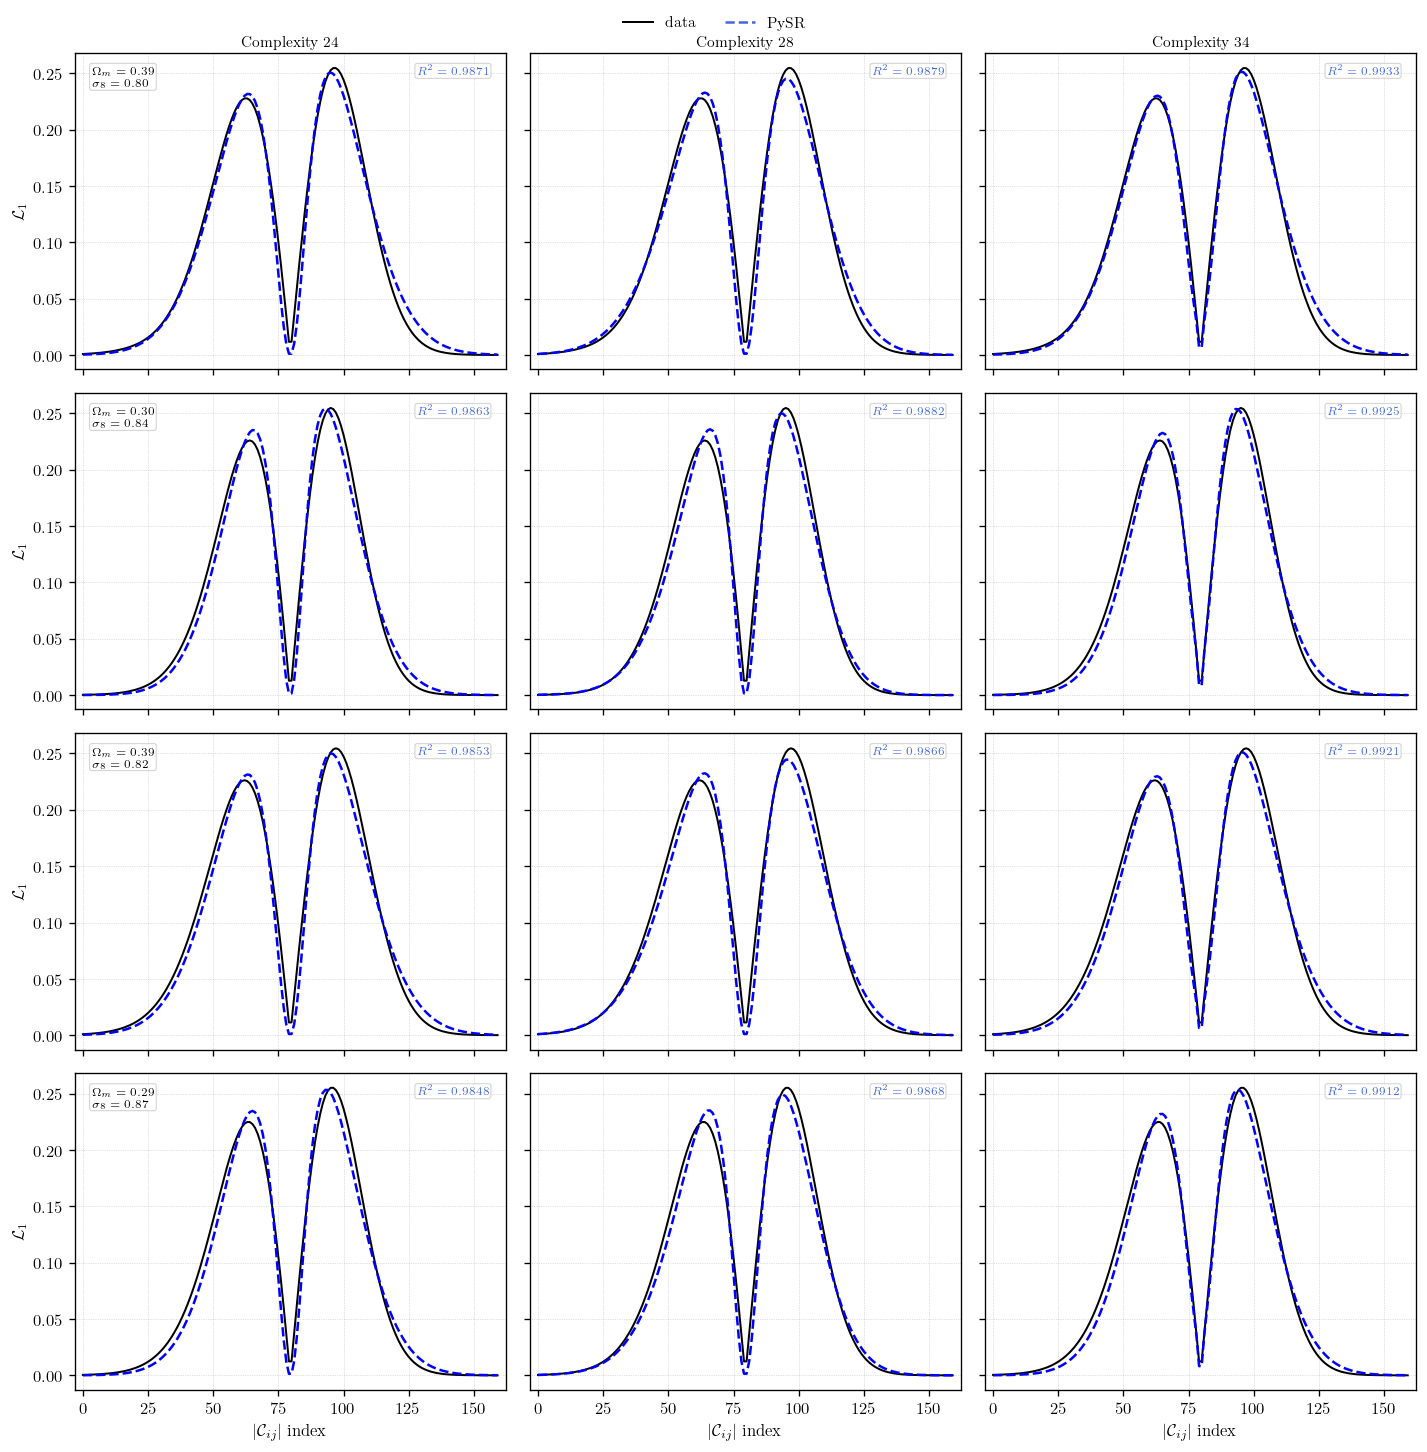

In [36]:
HOF = "/Users/arnablahiry/repos/SymReg-L1-Norm/pysr/direct_equation/outputs/20260323_020048_jUwwTB_50nodes_new_best/hall_of_fame.csv"

# Compare three complexity levels on the worst test cosmologies
fig, axes = plot_complexity_comparison(
    cosmo_test, dv_test, x_arr, x_c, scaler,
    hall_of_fame_csv=HOF,
    complexities=[24, 28, 34],
    idx=worst_idx(r2_all, n=4),
)
fig.savefig("complexity_comparison.pdf", bbox_inches="tight")

# Or just get predictions for complexity 18 alone
y18, r2_18, eq18 = predict_at_complexity(18, HOF, cosmo_test, dv_test, x_arr, x_c, scaler)
print(f"Complexity 18 median R²: {np.median(r2_18):.4f}")